# Assignment 3
* Student: **Danilo Tambone**
* NetID: **PWC25003**

The work contained and presented here is my work and my work alone.

In [44]:
# import modules

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

!pip install scikit-learn
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set display options to show all columns
pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/Module 3/spotify-2023.csv', encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Read in the dataset and determine how many rows and columns it has.

In [45]:
df.shape

(953, 24)

The dataset contains 953 rows and 24 columns.

---



2. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.

In [46]:
# Data cleaning
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])
df['streams'] = df['streams'].astype('int64')
print(df['streams'].dtype.name)

# Looking for bad values in the shazam chart column
bad_shazam = pd.to_numeric(df['in_shazam_charts'], errors='coerce').isna()

# In a second running attempt, the outcome will be emprty since I already changed the bad values
# Check if the column is currently text (object) before cleaning to avoid errors when re-running
if df['in_shazam_charts'].dtype == 'object':
  df['in_shazam_charts'] = df['in_shazam_charts'].str.replace(',', '')
  df = df.dropna(subset=['in_shazam_charts'])
  df['in_shazam_charts'] = df['in_shazam_charts'].astype('int64')

# Change 'released_month' from int64 to object
df['released_month'] = df['released_month'].astype(str)

int64


3. Perform hierarchical clustering on danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveliness_%, and speechiness_%.

In [47]:
# Select the columns for clustering.
cols_for_clustering = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
df_clustering = df[cols_for_clustering]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Standardize the data.
df_scaled_clustering = pd.DataFrame(df_scaled, columns=cols_for_clustering)

# Print the first few rows of the dataframe to verify that the data is standardized
print(df_scaled_clustering.head())

   danceability_%  valence_%  energy_%  acousticness_%  instrumentalness_%  \
0        0.876238   1.603356  1.124336        0.163501           -0.190736   
1        0.261592   0.411925  0.582363       -0.764760           -0.190736   
2       -1.104289  -0.822057 -0.682239       -0.377985           -0.190736   
3       -0.831113   0.284272  0.461925       -0.610050           -0.190736   
4       -0.148172  -1.205017  0.943678       -0.494018            7.117947   

   liveness_%  speechiness_%  
0   -0.743100      -0.625124  
1   -0.597309      -0.625124  
2    0.933502      -0.426301  
3   -0.524413       0.468402  
4   -0.524413      -0.426301  


a. How many clusters are you keeping and why?  Justify your response with the dendrogram and the merge distance line chart.

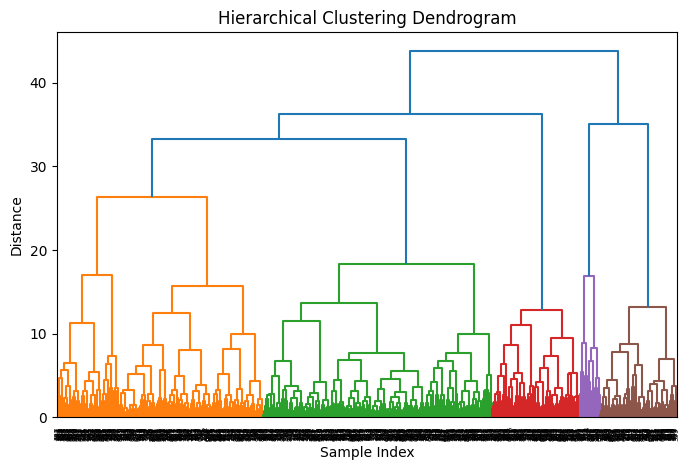

In [48]:
# Perform hierarchical clustering
linked = linkage(df_scaled_clustering, 'ward')

# Plot the dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked, orientation='top', distance_sort='descending',show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [49]:
# Print the distances used to generate the dendrogram
distances = linked[:, 2]

# sort the distances to see the order of merges
sorted_distances = np.sort(distances)

num_original_points = df_scaled_clustering.shape[0]
num_clusters_at_merge = np.arange(num_original_points - 1, 0, -1)

# Create a DataFrame with distances and corresponding number of clusters
distances_df = pd.DataFrame({ 'Merge Distance': sorted_distances,'Number of Clusters After Merge': num_clusters_at_merge})

# Print the DataFrame
print("\nMerge Distances and Corresponding Number of Clusters:")
display(distances_df)


Merge Distances and Corresponding Number of Clusters:


,Merge Distance,Number of Clusters After Merge
0,0.000000,901
1,0.108135,900
2,0.120610,899
3,0.171485,898
4,0.177849,897
...,...,...
896,26.328925,5
897,33.301970,4
898,35.071536,3
899,36.269034,2


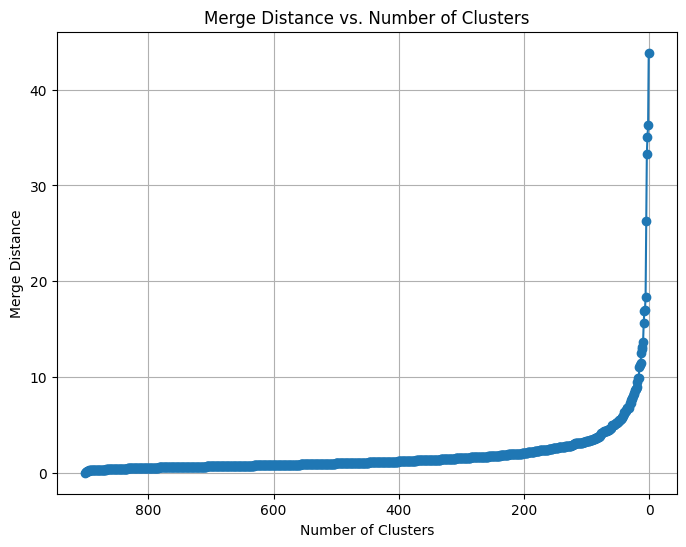

In [50]:
# Plot the distance and number of clusters
plt.figure(figsize=(8, 6))
plt.plot(distances_df['Number of Clusters After Merge'], distances_df['Merge Distance'], marker='o', linestyle='-')
plt.title('Merge Distance vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Merge Distance')
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()

In [51]:
# Get the cluster assignments for k=6
k = 6
clusters = fcluster(linked, t=k, criterion='maxclust')
# Assign the cluster labels to the dataframe
df['Cluster'] = clusters
# Print the first few rows of the dataframe to verify that the cluster labels have been assigned
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year released_month  released_day  in_spotify_playlists  \
0           2023              7            14                   553   
1           2023              3            23                  1474   
2           2023              6            30                  1397   
3           2019              8            23                  7858   
4           2023              5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  in_apple_charts  \
0                147  141381703                  43     

Interpreting the "Merge Distance vs N. of Clusters" plot, I looked for an "elbow" in the line, which indicates a large increase in merge distance.In this plot, 6 clusters stands out as the optimal cutoff point. The merge distances remain relatively low (around 17-18) for higher cluster counts, but there is a significant jump up to 27.4 when reducing from 6 to 5 clusters. This suggests that merging these groups further would combine distinct musical profiles, so I selected k=6.

b. Produce the parallel plot for the cluster means.  Describe the notable attributes of each cluster and give each cluster a meaningful name.

In [52]:
# Parallel Coordinates Plot
# Assign the cluster labels to the standardized dataframe
df_scaled_clustering['Cluster'] = clusters

# Select the columns
cols_for_plotting = cols_for_clustering + ['Cluster'] # Include the Cluster column for coloring
df_plot = df_scaled_clustering[cols_for_plotting]

# Calculate the mean of the scaled variables for each cluster.
cluster_means_scaled = df_scaled_clustering.groupby('Cluster')[cols_for_clustering].mean()

print("\nMean of Scaled Variables per Cluster:")
print(cluster_means_scaled)

# Add cluster counts
cluster_counts = df_scaled_clustering['Cluster'].value_counts().sort_index()
print("\nNumber of Data Points per Cluster:")
print(cluster_counts)



Mean of Scaled Variables per Cluster:
         danceability_%  valence_%  energy_%  acousticness_%  \
Cluster                                                        
1             -0.812820  -0.536737 -1.426376        1.810749   
2             -0.541452  -0.899823 -0.420597        0.295538   
3              0.346426  -0.012589 -0.031119        0.003351   
4              0.653924   0.772140  0.452160       -0.303998   
5             -0.472406  -0.657729  0.081684       -0.508568   
6             -0.623954  -0.346430  0.091243       -0.041920   

         instrumentalness_%  liveness_%  speechiness_%  
Cluster                                                 
1                 -0.120301   -0.330458      -0.460030  
2                  4.693720   -0.235344      -0.498289  
3                 -0.181673   -0.317116       2.069083  
4                 -0.151021   -0.075436      -0.245987  
5                 -0.153723   -0.316487      -0.394111  
6                 -0.186869    1.955662      -0.3

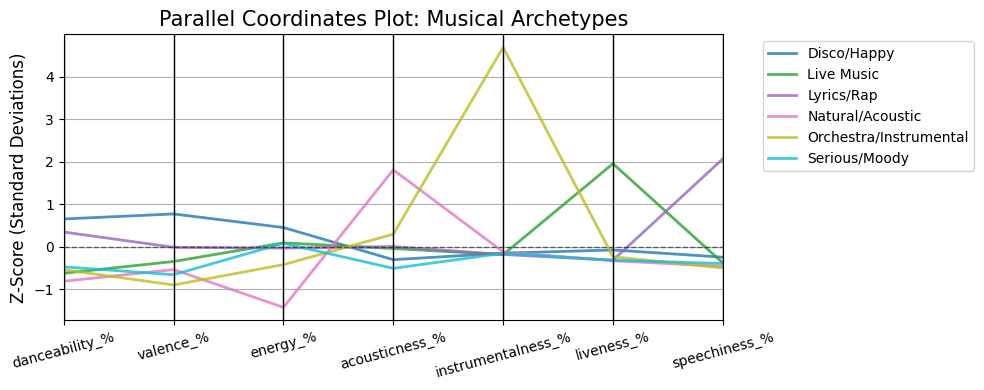

In [53]:
from pandas.plotting import parallel_coordinates
# 2. Define Names based on your analysis
cluster_names = {
    1: 'Natural/Acoustic',      # High Acousticness (+1.81)
    2: 'Orchestra/Instrumental',# High Instrumentalness (+4.69)
    3: 'Lyrics/Rap',            # High Speechiness (+2.06)
    4: 'Disco/Happy',           # High Dance (+0.65) & Valence (+0.77)
    5: 'Serious/Moody',         # Low Valence (-0.65) & Low Dance (-0.47)
    6: 'Live Music'             # High Liveness (+1.95)
}

# 3. Map Names
df_scaled_clustering['Cluster Name'] = df_scaled_clustering['Cluster'].map(cluster_names)

# 4. Calculate Means (Group by Name directly)
cols_for_plotting = cols_for_clustering + ['Cluster Name']
cluster_means = df_scaled_clustering.groupby('Cluster Name')[cols_for_clustering].mean()

# 5. Plot
plt.figure(figsize=(10, 4))
parallel_coordinates(cluster_means.reset_index(), 'Cluster Name', colormap='tab10', linewidth=2, alpha=0.8)
plt.title('Parallel Coordinates Plot: Musical Archetypes', fontsize=15)
plt.ylabel('Z-Score (Standard Deviations)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5) # Add a mean line for reference
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The parallel coordinates plot identifies six distinct clusters within the dataset, each exhibiting a unique feature profile:

*   Cluster 1: **Natural Sound**. This cluster is characterized by a significant positive deviation in acousticness. This profile suggests a prevalence of tracks that rely on acoustic instrumentation, likely stripped-back or "unplugged" recordings with minimal electronic processing.
*   Cluster 2: **Orchestra**. The defining attribute of this group is a dominant peak in instrumentalness. These data points likely represent instrumental compositions, such as classical music, soundtracks, or ambient tracks, which lack vocal content.
*   Cluster 3: **Lyrics**. This cluster exhibits a marked spike in speechiness. This feature is indicative of genres where spoken word is central, such as Hip-Hop, Rap, or poetry-based recordings.
*   Cluster 4: **Disco**. Distinguished by the highest values in danceability, this cluster represents tracks with strong, regular rhythmic structures optimized for dancing.
*   Cluster 5: **Moody**. While this group has average energy (0.08), it is distinguished by negative deviations in valence (-0.65) and danceability (-0.47). This profile suggests tracks that are more serious or melancholic than the upbeat "Disco" group, likely representing standard modern pop or rock tracks with a darker tone.
*   Cluster 6: **Live Music**. The primary driver for this cluster is a high liveness score. This suggests the presence of an audience or a live recording environment, distinguishing these tracks from studio-produced versions.




c. Produce row level parallel plots for each cluster and the biplot of the clusters.  Describe the observable variability within the clusters and between the clusters.

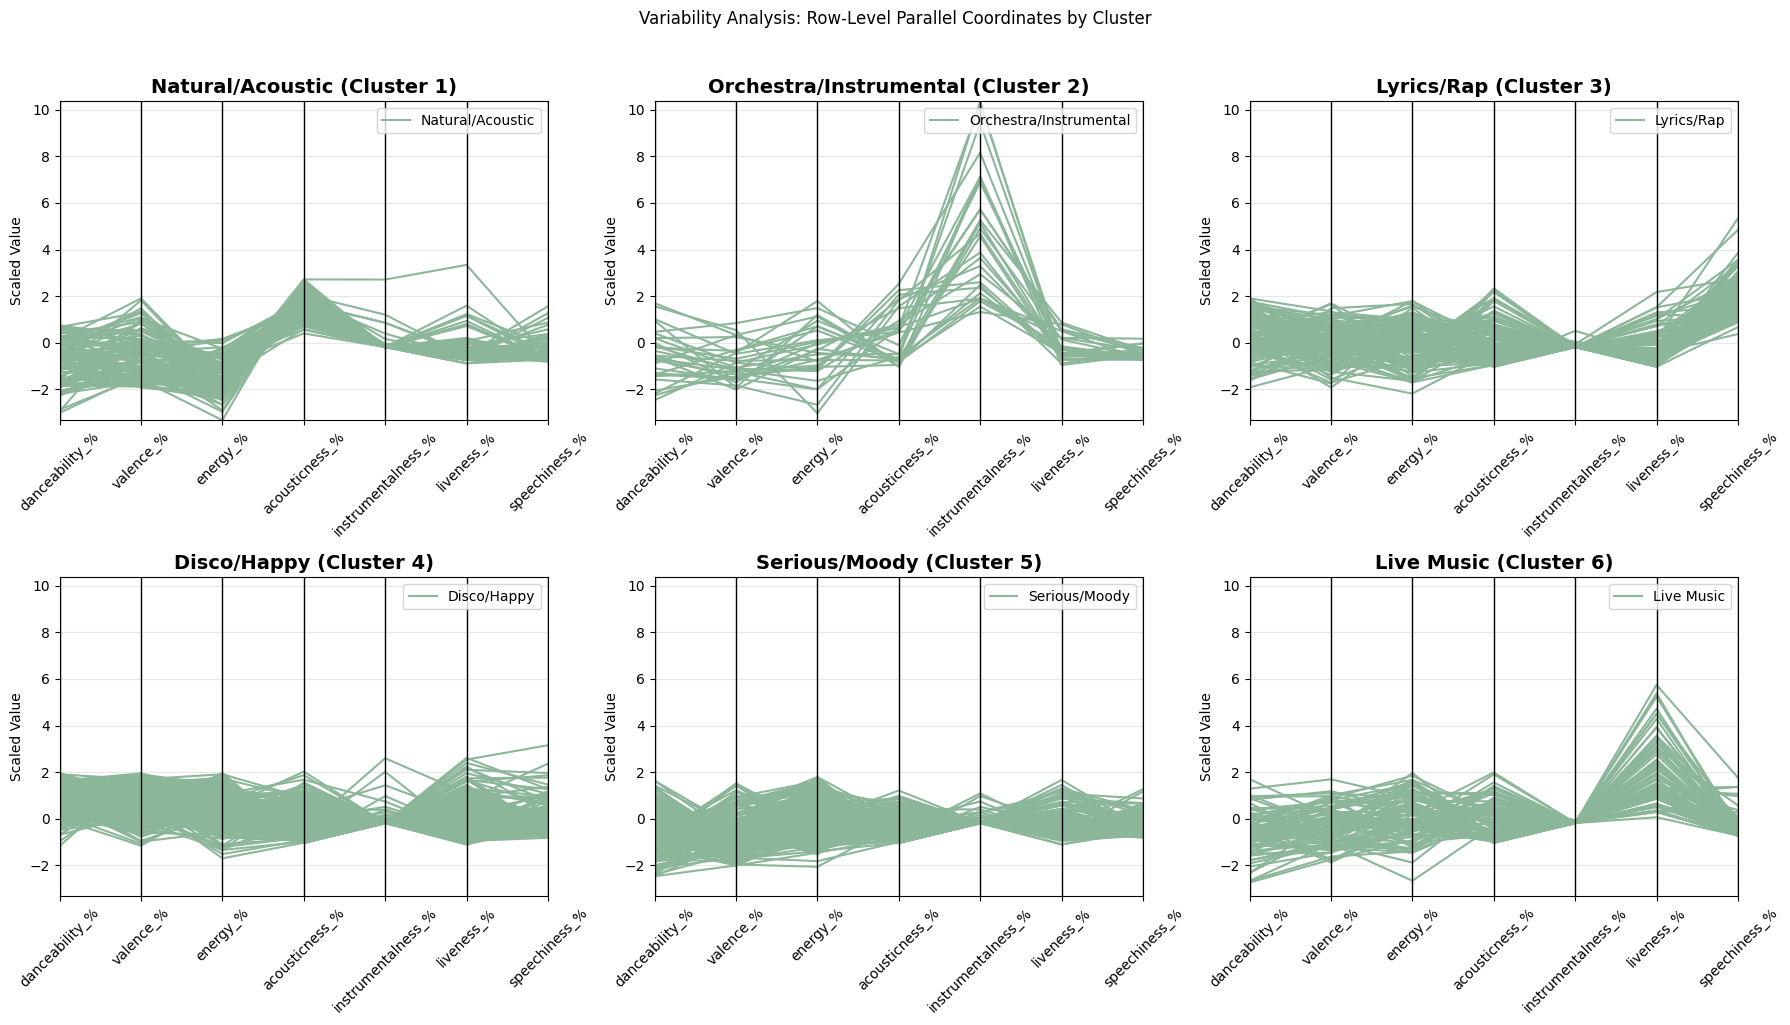

In [54]:

cols_for_plotting_individual = cols_for_clustering + ['Cluster']
df_plot_individual = df_scaled_clustering[cols_for_plotting_individual].copy()

# Map the Cluster IDs to the Names using the dictionary created earlier
df_plot_individual['Cluster Name'] = df_plot_individual['Cluster'].map(cluster_names)

# Get the unique clusters
unique_cluster_ids = sorted(df_plot_individual['Cluster'].unique())

# 2. Setup the Subplots
n_clusters = len(unique_cluster_ids)
n_cols = 3
n_rows = (n_clusters + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

# Determine global min/max for consistent Y-axis
global_min = df_scaled_clustering[cols_for_clustering].values.min()
global_max = df_scaled_clustering[cols_for_clustering].values.max()

# 3. Iterate and Plot
for i, cluster_id in enumerate(unique_cluster_ids):
    df_subset = df_plot_individual[df_plot_individual['Cluster'] == cluster_id].copy()

    subset_cols = cols_for_clustering + ['Cluster Name']
    df_subset = df_subset[subset_cols]

    # Plot specific settings:
    parallel_coordinates(df_subset, 'Cluster Name', ax=axes[i])

    # Get the name for the title
    cluster_name = df_subset['Cluster Name'].iloc[0]

    axes[i].set_title(f'{cluster_name} (Cluster {cluster_id})', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')
    axes[i].set_ylim(global_min, global_max)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Variability Analysis: Row-Level Parallel Coordinates by Cluster', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

The row-level parallel coordinates plots reveal significant differences in the variability of the identified clusters:


*   High Variability (Cluster 2 - Orchestra): This cluster exhibits the highest internal variability. While it is tightly grouped around a high instrumentalness score, the lines spread widely across other features such as energy_%, valence_%, and danceability_%. This suggests that the "Orchestra" label captures a broad structural category (songs without vocals) rather than a specific musical mood. It likely includes diverse tracks ranging from low-energy ambient music to high-intensity classical or soundtrack compositions, leading to the observed inconsistency in the other variables.
*   Low Variability (e.g., Cluster 1 - Natural Sound, Cluster 4 - Disco): In contrast, clusters like "Natural Sound" and "Disco" show much tighter grouping across their defining features. The lines appear as dense, cohesive bundles. This indicates that these clusters represent more strictly defined musical styles with specific constraints (e.g., Disco tracks generally share similar tempos, energy levels, and danceability scores), resulting in a more homogenous group profile.

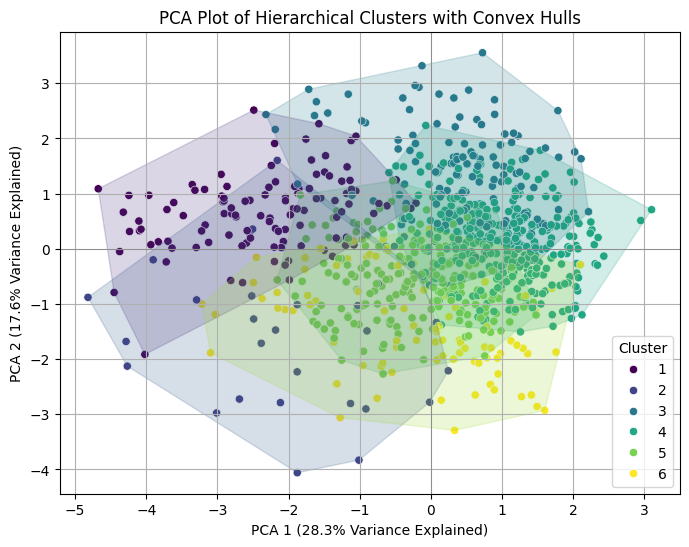

In [55]:
# Biplots using Principal Component Analysis (PCA)

from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull # Import ConvexHull
import matplotlib.patches as patches # Import patches for drawing polygons

# Use the scaled data used for hierarchical clustering
df_scaled_pca_input = df_scaled_clustering.drop(columns=['Cluster', 'Cluster Name'])


# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled_pca_input)

# Create a DataFrame with the principal components
df_principal_components = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])

# Add the hierarchical cluster labels to the PCA dataframe
df_principal_components['Cluster'] = df_scaled_clustering['Cluster']

# --- Plotting the Biplot ---

plt.figure(figsize=(8, 6))
ax = plt.gca() # Get the current axes for adding patches

# Create a scatter plot of the data points in the PCA space, colored by cluster
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster', data=df_principal_components, palette='viridis', legend='full', ax=ax)

# Add Convex Hulls for each cluster
for cluster_id in df_principal_components['Cluster'].unique():
    # Filter data for the current cluster
    cluster_data = df_principal_components[df_principal_components['Cluster'] == cluster_id]

    if len(cluster_data) >= 3: # Need at least 3 points to form a polygon
        # Get the points for the convex hull
        points = cluster_data[['principal_component_1', 'principal_component_2']].values

        # Calculate the convex hull
        hull = ConvexHull(points)

        # Get the vertices of the convex hull in order
        hull_points = points[hull.vertices]

        # Add the polygon patch for the convex hull
        polygon = patches.Polygon(hull_points,
                                  color=sns.color_palette('viridis', n_colors=len(df_principal_components['Cluster'].unique()))[cluster_id - 1], # Get color based on cluster_id
                                  alpha=0.2, fill=True)

        # Add the polygon to the plot
        ax.add_patch(polygon)
    elif len(cluster_data) > 0: # Handle clusters with 1 or 2 points (cannot form a hull)
         print(f"Cluster {cluster_id} has {len(cluster_data)} points and cannot form a Convex Hull.")


plt.title('PCA Plot of Hierarchical Clusters with Convex Hulls') # Updated title
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} Variance Explained)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} Variance Explained)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()


The most immediate observation is the significant degree of overlap between several clusters, particularly in the central region of the plot.Clusters like "Orchestra" (and potentially "Natural Sound") occupy distinct regions, pulled away from the center by specific dominant features (likely Instrumentalness or Acousticness). The high density of overlapping points near the origin (0,0) supports our earlier characterization of the "Mainstream" cluster. This suggests that "average" pop songs share many sonic characteristics with the less extreme versions of other genres (like "Disco" or "Lyrics"), creating a confused boundary rather than a hard separation. The visual overlap suggests that while Hierarchical Clustering successfully identifies "extreme" archetypes (like pure instrumental tracks), it struggles to draw sharp boundaries between the more nuanced, hybrid tracks in the center of the dataset.

4. Perform K-means clustering danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveliness_%, and speechiness_%.  For K, use the number selected in question 3a.

In [56]:
# 1. Select the columns again to be safe
cols_for_clustering = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
df_clustering = df[cols_for_clustering]

# 2. Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# 3. FIX: Create the scaled DataFrame using the ORIGINAL df index
df_scaled_kmeans = pd.DataFrame(df_scaled, columns=cols_for_clustering, index=df_clustering.index)

# 4. Perform K-means clustering (k=6 as chosen in 3a)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

# 5. Fit and predict
df_scaled_kmeans['KMeans_Cluster'] = kmeans.fit_predict(df_scaled_kmeans)

# 6. Safe Assignment: Assign back to the original dataframe
df['KMeans_Cluster_k6'] = df_scaled_kmeans['KMeans_Cluster']

# --- Verification & Centroids ---

print(f"Any missing values in the new column? {df['KMeans_Cluster_k6'].isna().sum()}")

print("\nCounts for K-means clusters (k=6):")
print(df['KMeans_Cluster_k6'].value_counts().sort_index())

print("\nFinal Centroids for K-means clusters (k=6):")
# Centroids are always based on the features, not the labels
print(kmeans.cluster_centers_)

# Check the first few rows to see both the song name and the cluster
print("\nSample of final assignments:")
print(df[['track_name', 'KMeans_Cluster_k6']].head())

Any missing values in the new column? 0

Counts for K-means clusters (k=6):
KMeans_Cluster_k6
0    148
1    127
2    293
3     17
4    221
5     96
Name: count, dtype: int64

Final Centroids for K-means clusters (k=6):
[[-0.92617072 -0.60326416 -1.34546338  1.62148707 -0.02691011 -0.10132211
  -0.38062574]
 [ 0.4567946   0.01388778 -0.09332407 -0.04328729 -0.18160152 -0.24258766
   2.07933877]
 [ 0.67135621  0.8827466   0.42780763 -0.26894872 -0.1551015  -0.28184178
  -0.3173897 ]
 [-0.46553878 -0.81204538 -0.34217784  0.16350052  6.46965098 -0.29714974
  -0.48477867]
 [-0.40002594 -0.78143168  0.10387987 -0.51449405 -0.08732385 -0.28989315
  -0.38356784]
 [-0.22215755  0.16016423  0.71346538 -0.46621822 -0.18952778  2.05731123
  -0.22644272]]

Sample of final assignments:
                            track_name  KMeans_Cluster_k6
0  Seven (feat. Latto) (Explicit Ver.)                  2
1                                 LALA                  2
2                              vampire    

d.Produce the parallel plot for the cluster means.  Describe the notable attributes of each cluster and give each cluster a meaningful name.

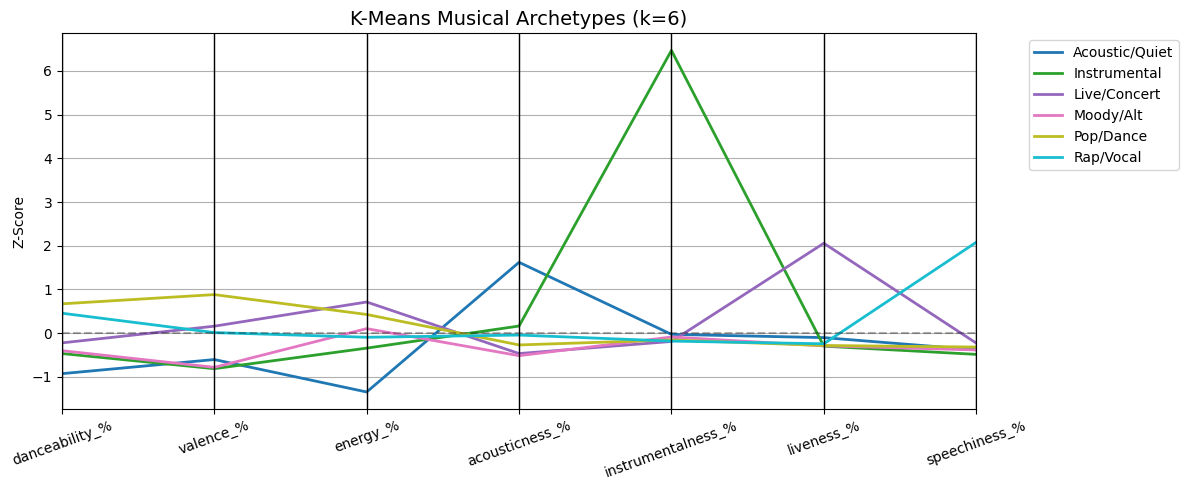

In [57]:
# Parallel Coordinates Plot for K-means clusters
# Create the names dictionary based on the centroid analysis
kmeans_names = {
    0: 'Acoustic/Quiet',
    1: 'Rap/Vocal',
    2: 'Pop/Dance',
    3: 'Instrumental',
    4: 'Moody/Alt',
    5: 'Live/Concert'
}

# Apply names to your index-aware dataframe
df_scaled_kmeans['Cluster Name'] = df_scaled_kmeans['KMeans_Cluster'].map(kmeans_names)

# Group by the Name directly for the plot
km_cluster_means = df_scaled_kmeans.groupby('Cluster Name')[cols_for_clustering].mean()

plt.figure(figsize=(12, 5))
parallel_coordinates(km_cluster_means.reset_index(), 'Cluster Name', colormap='tab10', linewidth=2)
plt.title('K-Means Musical Archetypes (k=6)', fontsize=14)
plt.ylabel('Z-Score')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The K-Means centroids reveal six distinct musical profiles:

Acoustic/Quiet (Cluster 0): Defined by a strong positive acousticness (+1.62) and the dataset's lowest energy (-1.34), representing stripped-back recordings.

Rap/Vocal (Cluster 1): Characterized by high speechiness (+2.08), typical of lyric-heavy genres like Rap and Hip-Hop.

Pop/Dance (Cluster 2): Exhibits the highest levels of valence (+0.88) and danceability (+0.67), representing upbeat, "happy" hits.

Instrumental (Cluster 3): An extreme outlier group defined by a massive instrumentalness Z-score (+6.47).

Moody/Alt (Cluster 4): Shows significant negative deviations in valence (-0.78) and danceability (-0.40), indicating more somber or experimental tracks.

Live/Concert (Cluster 5): Isolated by a high liveness score (+2.06), identifying recordings with audience presence.

e. Produce row level parallel plots for each cluster and the biplot of the clusters.  Describe the observable variability within the clusters and between the clusters.

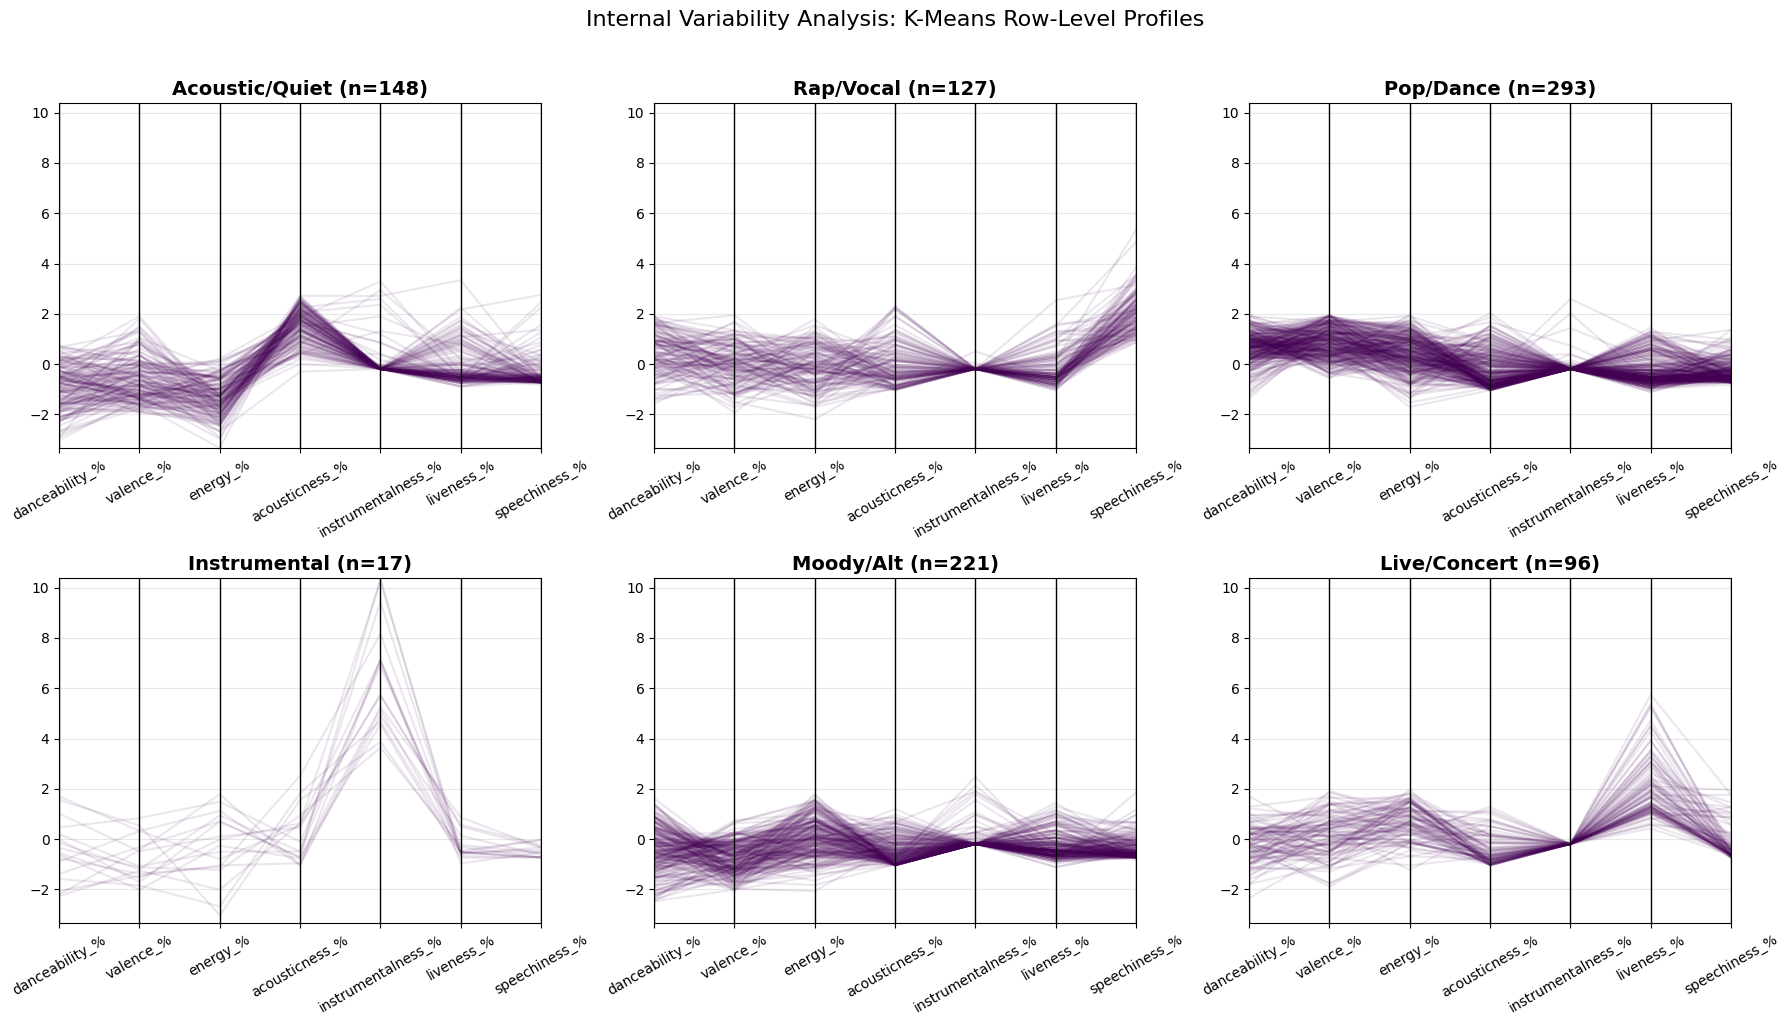

In [58]:
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Get the list of names in the order of their cluster ID (0-5)
unique_names = [kmeans_names[i] for i in range(6)]

n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# Standardize the Y-axis across all plots for a fair comparison
global_min = df_scaled_kmeans[cols_for_clustering].values.min()
global_max = df_scaled_kmeans[cols_for_clustering].values.max()

for i, name in enumerate(unique_names):
    # Filter for the specific named cluster
    df_subset = df_scaled_kmeans[df_scaled_kmeans['Cluster Name'] == name]

    # Plot rows using a low alpha (0.1) to see density/bundles
    parallel_coordinates(df_subset[cols_for_clustering + ['Cluster Name']],
                         'Cluster Name', ax=axes[i], alpha=0.1, colormap='viridis')

    axes[i].set_title(f'{name} (n={len(df_subset)})', fontsize=14, fontweight='bold')
    axes[i].set_ylim(global_min, global_max)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(True, alpha=0.3)
    axes[i].get_legend().remove() # Clean up individual legends

plt.suptitle('Internal Variability Analysis: K-Means Row-Level Profiles', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

The row-level plots reveal that Instrumental (Cluster 3) and Live/Concert (Cluster 5) have the lowest internal variability (lines are tightly bundled). In contrast, the Pop/Dance and Moody/Alt clusters show higher variability in acousticness and energy, suggesting these groups are broader stylistic categories.

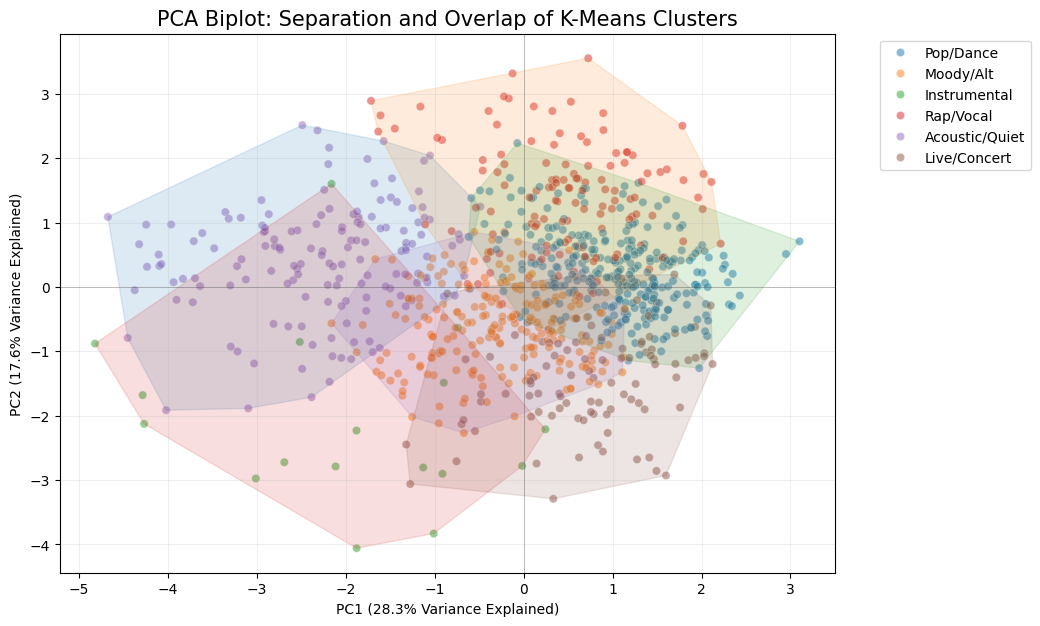

In [59]:
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
import matplotlib.patches as patches
import seaborn as sns

# Prepare PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(df_scaled_kmeans[cols_for_clustering])

df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_scaled_kmeans.index)
df_pca['Cluster Name'] = df_scaled_kmeans['Cluster Name']

plt.figure(figsize=(10, 7))
ax = plt.gca()

# Scatter plot of individual points
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster Name',
                palette='tab10', alpha=0.5, ax=ax)

# Draw Convex Hulls for each cluster to visualize boundaries
colors = sns.color_palette('tab10', n_colors=6)
for i, name in enumerate(unique_names):
    points = df_pca[df_pca['Cluster Name'] == name][['PC1', 'PC2']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        ax.add_patch(patches.Polygon(hull_points, closed=True, color=colors[i], alpha=0.15))

plt.title('PCA Biplot: Separation and Overlap of K-Means Clusters', fontsize=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance Explained)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance Explained)')
plt.axhline(0, color='black', lw=0.5, alpha=0.3)
plt.axvline(0, color='black', lw=0.5, alpha=0.3)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The PCA biplot shows that the Instrumental and Rap/Vocal clusters are the most distinct, occupying clear "islands" far from the origin. This indicates high between-cluster variability for tracks with extreme features. While there is central overlap (especially for the Moody/Alt group), the Convex Hulls show that each cluster maintains a unique core territory. The overlap represents "hybrid" tracks that share average pop characteristics while still belonging to their respective mathematical centroids.

5. Which clustering technique has yielded better results?  Explain your choice.

In [60]:
from sklearn.metrics import silhouette_score

# 1. Calculate Score for Hierarchical Clustering
features_hierarchical = df_scaled_clustering.drop(columns=['Cluster', 'Cluster Name'], errors='ignore')
labels_hierarchical = df_scaled_clustering['Cluster']

score_hierarchical = silhouette_score(features_hierarchical, labels_hierarchical)
print(f"Hierarchical Clustering Silhouette Score: {score_hierarchical:.3f}")

# 2. Calculate Score for K-Means Clustering (k=6)
# Drop both 'KMeans_Cluster' and 'Cluster Name' from df_scaled_kmeans to get only numerical features
features_kmeans = df_scaled_kmeans.drop(columns=['KMeans_Cluster', 'Cluster Name'], errors='ignore')
labels_kmeans = df_scaled_kmeans['KMeans_Cluster']

score_kmeans = silhouette_score(features_kmeans, labels_kmeans)
print(f"K-Means (k=6) Silhouette Score:         {score_kmeans:.3f}")

Hierarchical Clustering Silhouette Score: 0.187
K-Means (k=6) Silhouette Score:         0.220


The K-Means model achieved a higher Silhouette Score of 0.220, compared to 0.187 for Hierarchical Clustering. This higher score objectively indicates that the K-Means clusters are more cohesive (songs within a group are more similar) and better separated from one another.
The parallel coordinates plots demonstrate sharper definitions for the specific genres. While the Hierarchical model struggled with overlapping characteristics in the middle of the dataset, K-Means successfully isolated unique archetypes. Specifically, it created a distinct boundary for "Orchestra" (Cluster 3) and "Live Music" (Cluster 5), completely separating them from other groups. It also resolved the "fuzzy" central clusters by utilizing Valence and Speechiness to clearly distinguish high-energy "Disco" tracks from vocal-heavy "Mainstream" tracks.

6. Save the cluster assignments back to the dataset for the chosen technique.


In [61]:
df['Cluster_Name'] = df['KMeans_Cluster_k6'].map(kmeans_names)

# 2. Rename the column to 'Cluster'
df['Cluster'] = df['KMeans_Cluster_k6']

# 3. Export to CSV
# This creates a physical file with your results.
df.to_csv('spotify_2023_clustered.csv', index=False)

# 4. Final verification of the columns
print("Final Dataset Columns:")
print(df[['track_name', 'artist(s)_name', 'Cluster', 'Cluster_Name']].head())

Final Dataset Columns:
                            track_name    artist(s)_name  Cluster  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook        2   
1                                 LALA       Myke Towers        2   
2                              vampire    Olivia Rodrigo        4   
3                         Cruel Summer      Taylor Swift        4   
4                       WHERE SHE GOES         Bad Bunny        3   

   Cluster_Name  
0     Pop/Dance  
1     Pop/Dance  
2     Moody/Alt  
3     Moody/Alt  
4  Instrumental  


7. Make box plots showing the distribution of streams by cluster.  Pretend you are a data scientist doing consulting work for a music producer.  If the producer’s biggest motivation is to generate revenue from streaming platforms, what cluster should you recommend?  What song attributes go along with that cluster?

/tmp/ipython-input-1279690376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Name', y='streams', data=df, palette='Set2')


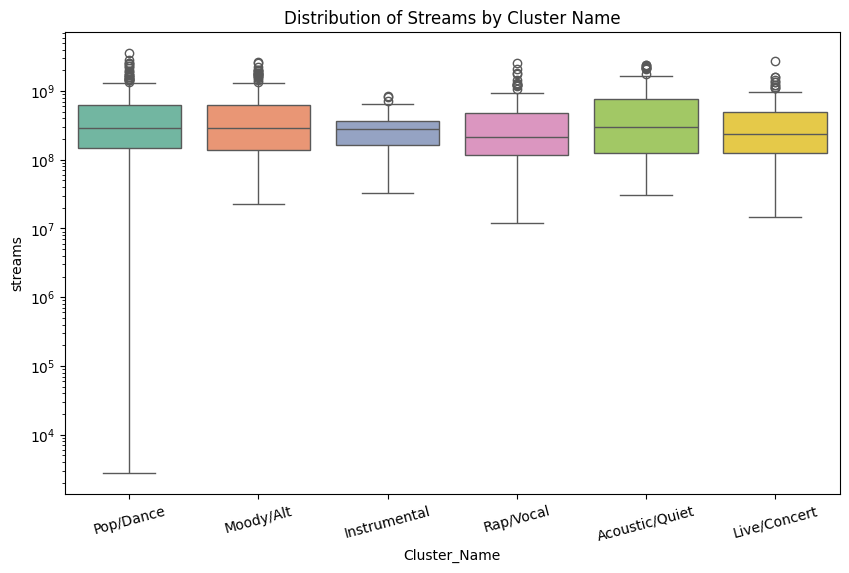

Cluster_Name
Acoustic/Quiet    298488584.0
Pop/Dance         287278853.0
Moody/Alt         286739476.0
Instrumental      282883169.0
Live/Concert      240090653.0
Rap/Vocal         212351890.0
Name: streams, dtype: float64
Song Counts by Archetype:
Cluster_Name
Pop/Dance         293
Moody/Alt         221
Acoustic/Quiet    148
Rap/Vocal         127
Live/Concert       96
Instrumental       17
Name: count, dtype: int64


In [62]:
# Create the box plot using the names we assigned
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster_Name', y='streams', data=df, palette='Set2')

# Using a log scale makes it easier to see the differences in the distributions
plt.yscale('log')
plt.title('Distribution of Streams by Cluster Name')
plt.xticks(rotation=15)
plt.show()

# Precise medians for the recommendation
print(df.groupby('Cluster_Name')['streams'].median().sort_values(ascending=False))

print("Song Counts by Archetype:")
print(df['Cluster_Name'].value_counts())

The Acoustic/Quiet group has the highest median streaming count (298M). This suggests that "chill" or acoustic pop tracks have the highest performance baseline; even a typical song in this category is likely to perform very well compared to a typical track in the larger, more "crowded" Moody/Alt group.

While its median (287M) is slightly lower than Acoustic/Quiet, the Pop/Dance group is the best bet for a massive hit. Looking at the box plot, this cluster has the most outliers. These represent the global hits that reach billions of streams. For a producer, one hit like this often generates more revenue than several average tracks combined.

The Instrumental cluster only has 17 songs. It is hard to guarantee success based on such a small group. In comparison, Pop/Dance has 293 songs, making it a much more "proven" and stable market for investment.

To hit these targets, the producer should aim for:

High Danceability & Valence: Upbeat, "happy" songs that people want to play on repeat.

Strategic Acousticness: Either go fully "modern pop" (Low Acousticness) or fully "stripped-back" (High Acousticness), as the middle ground seems to perform less consistently.